Using device: cpu
Loaded pretrained weights for efficientnet-b0
Processing dataset for the first time...
Loading Microsoft Image Understanding dataset...
Dataset structure: DatasetDict({
    val: Dataset({
        features: ['id', 'image', 'prompt', 'ground_truth'],
        num_rows: 1280
    })
})
Available splits: dict_keys(['val'])
Processing val split...


100%|██████████| 1280/1280 [01:20<00:00, 15.97it/s]


Processed and saved 1280 images

Finding and visualizing similar images...


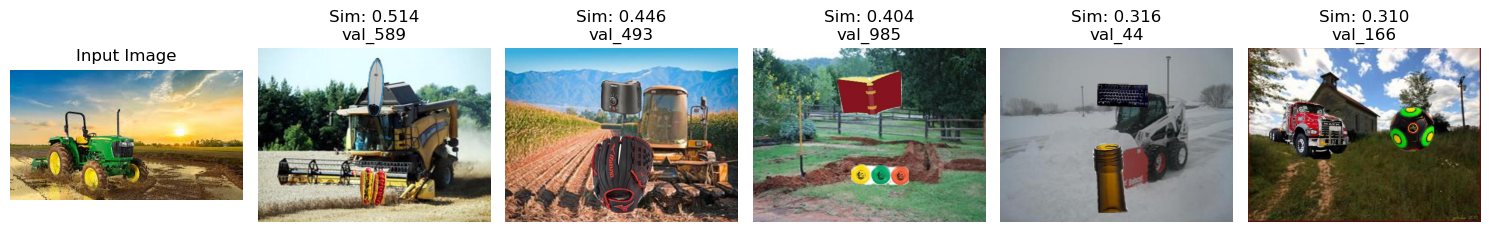

In [72]:
import torch
import torch.nn as nn
from efficientnet_pytorch import EfficientNet
from PIL import Image
import numpy as np
from datasets import load_dataset
import pickle
from tqdm import tqdm
import os
from torchvision import transforms
import matplotlib.pyplot as plt

class ImageSimilaritySearch:
    def __init__(self, image_size=224):
        """Initialize the similarity search system"""
        self.image_size = image_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        
        # Load and modify EfficientNet model
        self.model = self._build_model()
        self.model = self.model.to(self.device)
        self.model.eval()
        
        # Initialize transforms
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                              std=[0.229, 0.224, 0.225])
        ])
        
        self.features_database = None
        self.dataset_images = None
        self.image_indices = None

    def _build_model(self):
        """Build and return modified EfficientNet model"""
        model = EfficientNet.from_pretrained('efficientnet-b0')
        model._fc = nn.Identity()  # Remove final classification layer
        return model

    @torch.no_grad()
    def extract_features(self, image):
        """Extract features from a single image"""
        if isinstance(image, str):
            image = Image.open(image).convert('RGB')
        elif not isinstance(image, Image.Image):
            image = Image.fromarray(image).convert('RGB')
            
        img_tensor = self.transform(image).unsqueeze(0).to(self.device)
        features = self.model(img_tensor)
        features = features.cpu().numpy()
        return features.flatten()

    def process_dataset(self, save_path='features_database.pkl'):
        """Process the Microsoft Image Understanding dataset and save features"""
        # Load dataset
        print("Loading Microsoft Image Understanding dataset...")
        dataset = load_dataset("microsoft/IMAGE_UNDERSTANDING", "object_recognition_pairs")
        
        # Print dataset structure
        print("Dataset structure:", dataset)
        print("Available splits:", dataset.keys())
        
        features_list = []
        dataset_images = []
        image_indices = []
        
        # Process all splits
        for split in dataset.keys():
            print(f"Processing {split} split...")
            for idx, item in enumerate(tqdm(dataset[split])):
                # Process single image
                img = item['image']
                features = self.extract_features(img)
                features_list.append(features)
                dataset_images.append(img)
                image_indices.append(f"{split}_{idx}")
        
        # Convert to numpy array and normalize
        features_array = np.vstack(features_list)
        features_array = features_array / np.linalg.norm(features_array, axis=1)[:, np.newaxis]
        
        # Save features and metadata
        with open(save_path, 'wb') as f:
            pickle.dump({
                'features': features_array,
                'indices': image_indices
            }, f)
        
        self.features_database = features_array
        self.dataset_images = dataset_images
        self.image_indices = image_indices
        
        print(f"Processed and saved {len(features_list)} images")
        return features_array, dataset_images, image_indices

    def load_features_database(self, path='features_database.pkl'):
        """Load pre-processed features"""
        print("Loading pre-processed features...")
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.features_database = data['features']
        self.image_indices = data['indices']
        
        # Reload dataset to get images
        dataset = load_dataset("microsoft/IMAGE_UNDERSTANDING", "object_recognition_pairs")
        self.dataset_images = []
        for split in dataset.keys():
            for item in dataset[split]:
                self.dataset_images.append(item['image'])
        print(f"Loaded {len(self.image_indices)} images' features")

    def find_similar_images(self, input_image, top_k=5):
        """Find most similar images to the input image"""
        if self.features_database is None:
            raise ValueError("Features database not loaded. Call process_dataset or load_features_database first.")
        
        # Extract features from input image
        input_features = self.extract_features(input_image)
        input_features = input_features / np.linalg.norm(input_features)
        
        # Calculate similarities
        similarities = np.dot(self.features_database, input_features)
        
        # Get top K similar images
        top_indices = np.argsort(similarities)[-top_k:][::-1]
        top_similarities = similarities[top_indices]
        top_images = [self.dataset_images[i] for i in top_indices]
        top_metadata = [self.image_indices[i] for i in top_indices]
        
        return top_images, top_similarities, top_metadata

    def visualize_results(self, input_image, top_k=5):
        """Visualize input image and its most similar matches"""
        similar_images, similarities, metadata = self.find_similar_images(input_image, top_k)
        
        # Create subplot
        plt.figure(figsize=(15, 3))
        
        # Plot input image
        plt.subplot(1, top_k + 1, 1)
        plt.imshow(input_image)
        plt.title('Input Image')
        plt.axis('off')
        
        # Plot similar images
        for idx, (img, sim, meta) in enumerate(zip(similar_images, similarities, metadata)):
            plt.subplot(1, top_k + 1, idx + 2)
            plt.imshow(img)
            plt.title(f'Sim: {sim:.3f}\n{meta}')
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()

# Main execution
def main():
    # Initialize the system
    searcher = ImageSimilaritySearch()
    
    # Load your specific input image
    input_image = Image.open(r"C:\Users\Sumit\Downloads\New folder\download (2).jpg")
    
    # Process dataset if features don't exist
    if not os.path.exists('features_database.pkl'):
        print("Processing dataset for the first time...")
        searcher.process_dataset()
    else:
        searcher.load_features_database()
    
    # Visualize results
    print("\nFinding and visualizing similar images...")
    searcher.visualize_results(input_image, top_k=5)

if __name__ == "__main__":
    main()